# Exercise 1

#### Phytoplankton growth follows an exponential phase, at least for a certain period of time until resources may become limiting or other factors control the Malthusian growth

######  Plotting the pythoplankton growth contains data from a batch experiment conducted by Flynn et al. (1994).

#### AI decleration
 Gemini and ChatGPT was used to assist with fixing errors and improving the line of code and plot visuals refining it to add the description of the plots and some of the question were copied and paste from the exercise in order to get the code to be used.
> Example prompts that were used: 'how can i improve this plot should and add growth phases', 'help me fix this error i want to plot line of code to sperate this phases'.
> The prompt that i used to answer question 5 was to ask the AI to give ideas on how to anwer the question


In [7]:
# importing statement 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#Opening dataset files and reading dataset information (fynn)
df = pd.read_csv('HonsUCT_IntroOceMod/data/flynn94.csv')

In [9]:
#Opening first five row to check dataset
df.head()

,time,cells,biovolume,ammonium,cellC,chl-a
0,0.0,0.04,2.0,1.411,0.60,4.0
1,0.5,0.04,2.2,1.400,0.61,3.0
2,1.0,0.04,2.1,1.383,0.58,3.0
3,1.5,0.04,2.1,1.355,NaN,3.0
4,2.0,0.04,2.1,1.355,0.68,3.0


In [51]:
df.info

<bound method DataFrame.info of     time  cells  biovolume  ammonium  cellC  chl-a
0    0.0   0.04        2.0     1.411   0.60    4.0
1    0.5   0.04        2.2     1.400   0.61    3.0
2    1.0   0.04        2.1     1.383   0.58    3.0
3    1.5   0.04        2.1     1.355    NaN    3.0
4    2.0   0.04        2.1     1.355   0.68    3.0
5    2.5   0.05        2.6     1.350   0.66    4.0
6    3.0   0.05        NaN     1.355   0.75    6.0
7    3.5   0.05        NaN     1.333   2.29    9.0
8    4.0   0.04        2.1     1.316   2.91    9.0
9    4.5   0.06        2.9     1.288   1.75   14.0
10   5.0   0.05        2.3     1.288   1.49   14.0
11   5.5   0.05        NaN     1.260   2.14   17.0
12   6.0   0.10        NaN     1.257   1.58   18.0
13   6.5   0.10        NaN     1.226   2.07   41.0
14   7.0   0.15        7.4     1.226   2.04   41.0
15   7.5   0.15        NaN     1.092   2.66   50.0
16   8.0   0.23        NaN     1.092   2.25   53.0
17   8.5   0.22       13.4     0.935   4.12   68.0

In [52]:
# Extract key variables for plotting
time = df['time']
cells = df['cells']
ammonium = df['ammonium']
cell_c = df['cellC']
chl_a = df['chl-a']

#### 1 Plotting exponential growth
The exponential growth is not observed on the initial phase, everything is slowly growing from day 0-5.5 which is relatively constant in cells 0.1 and 0.2, and according to the phase growth graph on number 2 this is defined as the lag phase, where their are adapting to the introduced environement and there is resources available for growth, less competition. The next stage is the exponential phase, there is a drastical increase in the cells with time between days 6.5-15 and the increases from 0.1-1.5, this rapid growth shows that there is no resources limited and there are equally shared, and less resource competition. The last stage is the  stationary phase and this is where the less resources and the resource competion is very high, which indicates that some are out-competing other between day 19-25 and the cell slightly flucuates between 1.9-2 and this normal lead to death phase where the are no resources. Therefore there is an exponential growth observed.

C:\Users\zncnqu001\AppData\Local\Temp\ipykernel_49304\228455650.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


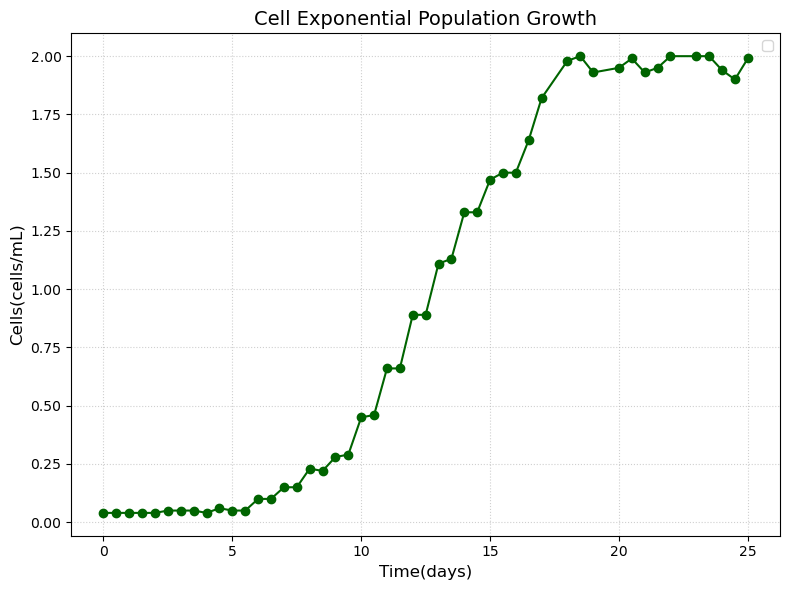

In [47]:
#plotting exponential growth graph
plt.figure(figsize=(8,6))
plt.plot(time, cells,'o-',color='darkgreen')
plt.xlabel('Time(days)', fontsize=12)
plt.ylabel('Cells(cells/mL)', fontsize=12)
plt.title('Cell Exponential Population Growth', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#### 2 Separate the growth curve into some phases

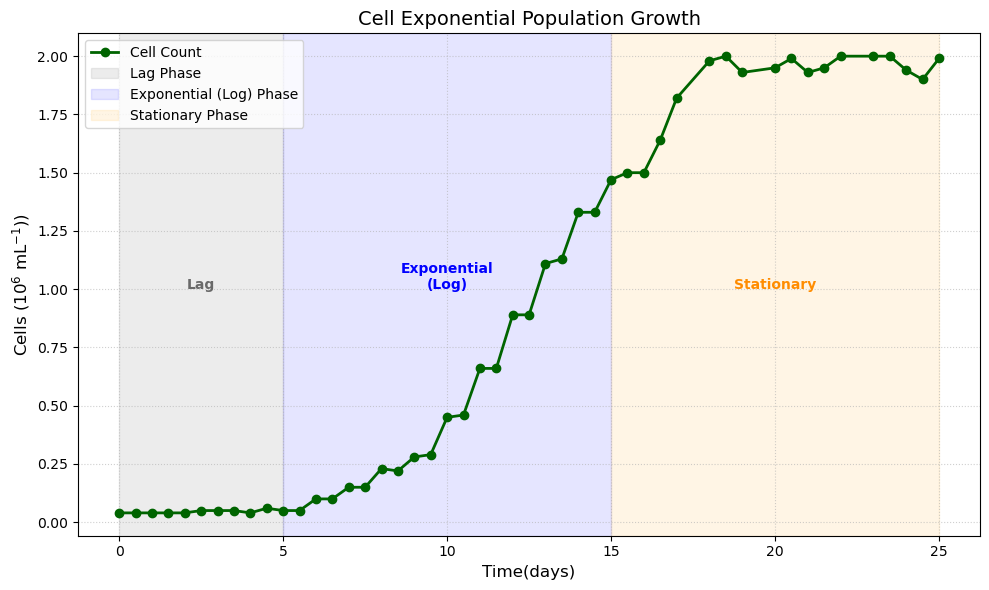

In [72]:
#Define the time boundaries for each phase based
lag_end = 5.0
log_end = 15.0
stationary_end = 25.0

#Plotting the exponential growth graph
plt.figure(figsize=(10, 6))
plt.plot(time, cells, "o-", color="darkgreen", label="Cell Count", linewidth=2)

# Add shaded background regions for each growth phase
plt.axvspan(0, lag_end, color="gray", alpha=0.15, label="Lag Phase")
plt.axvspan(lag_end, log_end, color="blue", alpha=0.1, label="Exponential (Log) Phase")
plt.axvspan(log_end, stationary_end, color="orange", alpha=0.1, label="Stationary Phase")


#  Add text annotations directly inside the graph for clarity
max_y = max(cells) if len(cells) > 0 else 1
plt.text(lag_end / 2,max_y * 0.5,"Lag",ha="center",fontweight="bold",color="dimgray",)
plt.text((lag_end + log_end) / 2,max_y * 0.5,"Exponential\n(Log)",ha="center",fontweight="bold",color="blue",)
plt.text((log_end + stationary_end) / 2,max_y * 0.5,"Stationary",ha="center",fontweight="bold",color="darkorange",)

# Styling and labels
plt.xlabel("Time(days)", fontsize=12)
plt.ylabel("Cells ($10^6$ mL$^{-1}$))", fontsize=12)
plt.title("Cell Exponential Population Growth", fontsize=14)
plt.grid(True, linestyle=":", alpha=0.6)

# Reposition legend so it doesn't cover data points
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 3 Growth expressed in cellular carbon from the one in cell number and chlorophyll
The cell number and cellular carbon have a relatively similar growth phase while chlorophyll reached it maximum relatively fast  and desrease and this phase is usually known as the death phase.


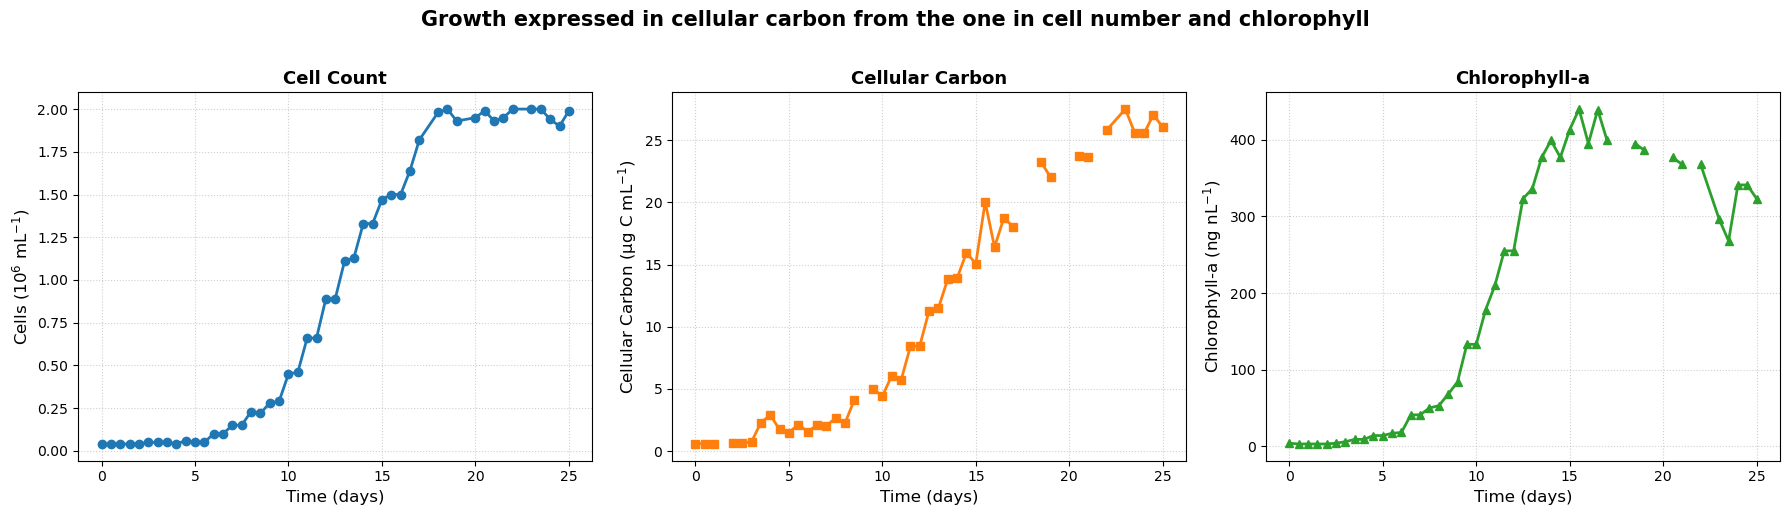

In [69]:
# Define Phase Boundaries
lag_end = 6.0
exp_end = 15.0
stat_end = 25.0

#  Create a 3-Panel Horizontal Plot
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5)) 

# Cell Number 
ax1.plot(time, cells, 'o-', color='tab:blue', linewidth=2)
ax1.set_ylabel('Cells ($10^6$ mL$^{-1}$)', fontsize=12)
ax1.set_xlabel('Time (days)', fontsize=12)
ax1.set_title('Cell Count', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

#  Panel 2: Cellular Carbon 
ax2.plot(time, cellC, 's-', color='tab:orange', linewidth=2)
ax2.set_ylabel('Cellular Carbon (µg C mL$^{-1}$)', fontsize=12)
ax2.set_xlabel('Time (days)', fontsize=12)
ax2.set_title('Cellular Carbon', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

#  Panel 3: Chlorophyll-a 
ax3.plot(time, chla, '^-', color='tab:green', linewidth=2)
ax3.set_ylabel('Chlorophyll-a (ng nL$^{-1}$)', fontsize=12)
ax3.set_xlabel('Time (days)', fontsize=12)
ax3.set_title('Chlorophyll-a', fontsize=13, fontweight='bold')
ax3.grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Growth expressed in cellular carbon from the one in cell number and chlorophyll', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 4 Ammonium consumption approximated by an exponential curve
The consumption of ammonium mirrors the exponential growth phase of the phytoplankton. It shows a downcurve of the exponential curve.

C:\Users\zncnqu001\AppData\Local\Temp\ipykernel_49304\1980603186.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


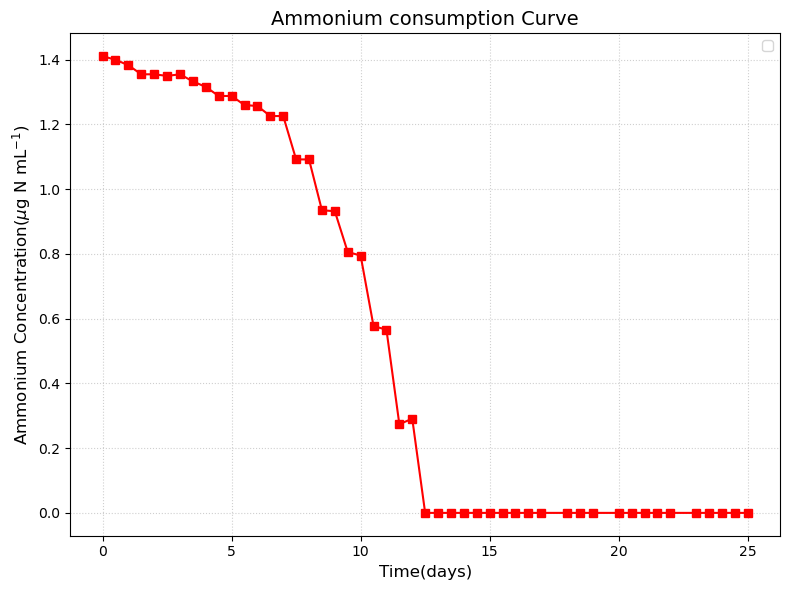

In [67]:
#Plotting ammonium curve

plt.figure(figsize=(8,6))
plt.plot(time, ammonium,'s-',color='red')
plt.xlabel('Time(days)', fontsize=12)
plt.ylabel('Ammonium Concentration($\mu$g N mL$^{-1}$)', fontsize=12)
plt.title('Ammonium consumption Curve', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Improved plots for question 3 

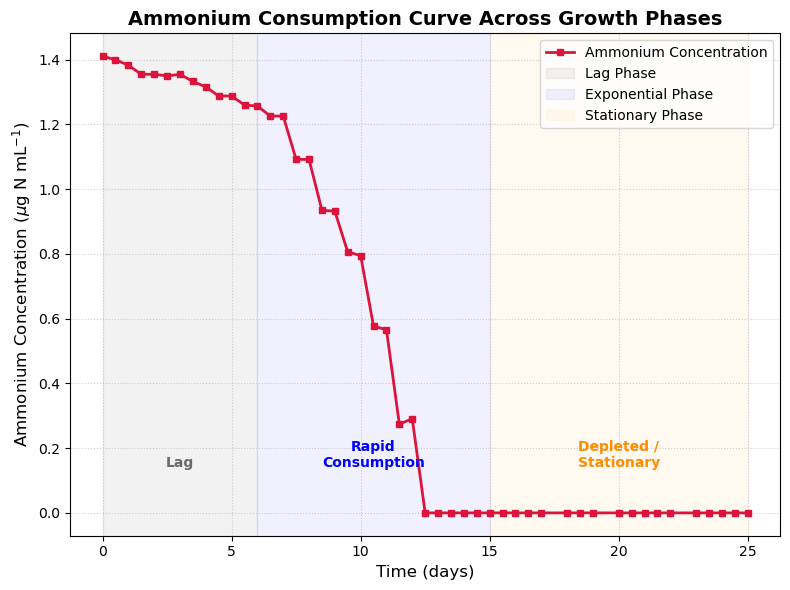

In [73]:


# . Phase Boundary Settings 
lag_end = 6.0
exp_end = 15.0
stat_end = 25.0

# Plotting Ammonium Consumption 
plt.figure(figsize=(8, 6))
plt.plot(
    time,
    ammonium,
    "s-",
    color="crimson",
    label="Ammonium Concentration",
    linewidth=2,
    markersize=5,
)

# Add Shaded Background Regions 
plt.axvspan(0, lag_end, color="gray", alpha=0.1, label="Lag Phase")
plt.axvspan(
    lag_end, exp_end, color="blue", alpha=0.06, label="Exponential Phase"
)
plt.axvspan(
    exp_end, stat_end, color="orange", alpha=0.06, label="Stationary Phase"
)

#  Adding Labels inside the graph 
max_y = max(ammonium) if len(ammonium) > 0 else 1.5
plt.text(
    lag_end / 2,
    max_y * 0.1,
    "Lag",
    ha="center",
    fontweight="bold",
    color="dimgray",
)
plt.text(
    (lag_end + exp_end) / 2,
    max_y * 0.1,
    "Rapid\nConsumption",
    ha="center",
    fontweight="bold",
    color="blue",
)
plt.text(
    (exp_end + stat_end) / 2,
    max_y * 0.1,
    "Depleted /\nStationary",
    ha="center",
    fontweight="bold",
    color="darkorange",
)

#  Graph Customization
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Ammonium Concentration ($\mu$g N mL$^{-1}$)", fontsize=12)
plt.title("Ammonium Consumption Curve Across Growth Phases", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

### Estimate the parameters of the growth curve
The first step is to choose a model or improve this model that will assist to estimate the parameters of the growth curve by introducting a non-linear model 
Provide an estimation of the growth rate
Look at the stationary phase panel and identify the average y-value where the population is stabilizes which is the carrying capacity (k)